# 03. Association Mining & Clustering

**Objectives:**
- Mine association patterns in power consumption states
- Generate and interpret association rules
- Cluster households based on consumption profiles
- Profile and interpret clusters

In [1]:
# Import libraries
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data.loader import PowerDataLoader
from src.mining.association import PowerAssociationMiner
from src.mining.clustering import PowerClusteringAnalyzer
from src.visualization.plots import PowerVisualizer
from src.evaluation.report import ReportGenerator

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## PART 1: ASSOCIATION PATTERN MINING

### 1.1 Load Data

In [3]:
# Load feature-engineered data
loader = PowerDataLoader(config_path='../configs/params.yaml')
df_features = loader.load_processed_data('features_data.parquet')

print(f"Data loaded: {df_features.shape}")
print(f"\nAvailable power state flags:")
state_cols = [col for col in df_features.columns if col.startswith('is_')]
for col in state_cols:
    print(f"  - {col}")

Loaded processed data from data\processed\features_data.parquet
Data loaded: (34589, 30)

Available power state flags:
  - is_outlier
  - is_weekend
  - is_night
  - is_peak_hour
  - is_off-peak
  - is_normal
  - is_peak


### 1.2 Prepare Transactions

In [4]:
# Initialize miner
miner = PowerAssociationMiner(config_path='../configs/params.yaml')

# Prepare transactions
transactions = miner.prepare_transactions(
    df_features,
    time_window='6H'  # Aggregate to 6-hour windows
)

print(f"\nTransactions shape: {transactions.shape}")
print(f"\nSample transactions:")
transactions.head(10)

Preparing transactions with 7 items...
Items: ['is_outlier', 'is_weekend', 'is_night', 'is_peak_hour', 'is_off-peak', 'is_normal', 'is_peak']
Created 5766 transactions

Transactions shape: (5766, 7)

Sample transactions:


,is_outlier,is_weekend,is_night,is_peak_hour,is_off-peak,is_normal,is_peak
datetime,,,,,,,
2006-12-16 12:00:00,False,True,False,False,False,True,False
2006-12-16 18:00:00,True,True,True,True,True,True,False
2006-12-17 00:00:00,True,True,True,False,True,True,False
2006-12-17 06:00:00,True,True,True,False,True,True,False
2006-12-17 12:00:00,True,True,False,False,True,True,False
2006-12-17 18:00:00,False,True,True,True,True,True,False
2006-12-18 00:00:00,False,False,True,False,True,False,False
2006-12-18 06:00:00,True,False,True,False,True,True,False
2006-12-18 12:00:00,False,False,False,False,True,False,False


### 1.3 Mine Frequent Itemsets

In [5]:
# Mine frequent itemsets
frequent_itemsets = miner.mine_frequent_itemsets(
    transactions,
    min_support=0.02,
    use_fp_growth=False
)

print(f"\nTop 10 frequent itemsets:")
frequent_itemsets.head(10)


Mining frequent itemsets (min_support=0.02)...
Using Apriori algorithm...
Found 45 frequent itemsets
Itemset lengths: {1: 7, 2: 17, 3: 21}

Top 10 frequent itemsets:


,support,itemsets,length
4,0.991849,(is_off-peak),1
2,0.749740,(is_night),1
18,0.742629,"(is_off-peak, is_night)",2
0,0.410163,(is_outlier),1
10,0.404093,"(is_off-peak, is_outlier)",2
5,0.317725,(is_normal),1
22,0.309573,"(is_normal, is_off-peak)",2
8,0.295699,"(is_night, is_outlier)",2
29,0.290323,"(is_off-peak, is_night, is_outlier)",3
1,0.285467,(is_weekend),1


### 1.4 Generate Association Rules

In [6]:
# Generate rules
rules = miner.generate_association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.5
)

# Filter rules
rules_filtered = miner.filter_rules(
    rules,
    min_confidence=0.6,
    min_lift=1.2
)

print(f"\nFiltered rules: {len(rules_filtered)}")
print(f"\nTop 10 rules by lift:")
rules_filtered.head(10)


Generating association rules (metric=confidence, min_threshold=0.5)...
Generated 69 rules

Filtered to 30 rules
  - Confidence >= 0.6
  - Lift >= 1.2
  - Support >= 0.01

Filtered rules: 30

Top 10 rules by lift:


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
68,(is_peak),"(is_normal, is_outlier)",0.021332,0.254422,0.020291,0.951220,3.738740,1.0,0.014864,15.284339,0.748497,0.079430,0.934574,0.515487
65,(is_peak),(is_normal),0.021332,0.317725,0.020465,0.959350,3.019438,1.0,0.013687,16.783975,0.683391,0.064235,0.940419,0.511880
67,"(is_peak, is_outlier)",(is_normal),0.021159,0.317725,0.020291,0.959016,3.018389,1.0,0.013569,16.647520,0.683152,0.063691,0.939931,0.511441
54,"(is_peak_hour, is_outlier)",(is_normal),0.158169,0.317725,0.121748,0.769737,2.422654,1.0,0.071494,2.963025,0.697562,0.343781,0.662507,0.576462
64,(is_peak),(is_outlier),0.021332,0.410163,0.021159,0.991870,2.418233,1.0,0.012409,72.549948,0.599258,0.051564,0.986216,0.521728
66,"(is_peak, is_normal)",(is_outlier),0.020465,0.410163,0.020291,0.991525,2.417393,1.0,0.011897,69.600763,0.598581,0.049451,0.985632,0.520498
57,"(is_weekend, is_normal)",(is_outlier),0.108914,0.410163,0.097815,0.898089,2.189591,1.0,0.053142,5.787775,0.609699,0.232194,0.827222,0.568283
36,(is_peak_hour),"(is_outlier, is_night)",0.250087,0.295699,0.158169,0.632455,2.138848,1.0,0.084218,1.916230,0.710027,0.408054,0.478142,0.583676
30,"(is_outlier, is_night)",(is_normal),0.295699,0.317725,0.189559,0.641056,2.017646,1.0,0.095609,1.900784,0.716133,0.447218,0.473901,0.618836
53,"(is_peak_hour, is_normal)",(is_outlier),0.147936,0.410163,0.121748,0.822978,2.006465,1.0,0.061070,3.331993,0.588701,0.279014,0.699879,0.559903


### 1.5 Interpret Rules

In [7]:
# Print human-readable interpretation
miner.interpret_rules(rules_filtered, top_n=10)


TOP 10 ASSOCIATION RULES

Rule 69:
  IF is_peak
  THEN is_normal, is_outlier
  Support: 0.0203
  Confidence: 0.9512
  Lift: 3.7387
  Interpretation: When is_peak occurs, is_normal, is_outlier occurs 95.1% of the time
                 (This is 3.74x more likely than random)

Rule 66:
  IF is_peak
  THEN is_normal
  Support: 0.0205
  Confidence: 0.9593
  Lift: 3.0194
  Interpretation: When is_peak occurs, is_normal occurs 95.9% of the time
                 (This is 3.02x more likely than random)

Rule 68:
  IF is_peak, is_outlier
  THEN is_normal
  Support: 0.0203
  Confidence: 0.9590
  Lift: 3.0184
  Interpretation: When is_peak, is_outlier occurs, is_normal occurs 95.9% of the time
                 (This is 3.02x more likely than random)

Rule 55:
  IF is_peak_hour, is_outlier
  THEN is_normal
  Support: 0.1217
  Confidence: 0.7697
  Lift: 2.4227
  Interpretation: When is_peak_hour, is_outlier occurs, is_normal occurs 77.0% of the time
                 (This is 2.42x more likely than 

### 1.6 Save Association Rules

In [8]:
# Save rules
reporter = ReportGenerator(config_path='../configs/params.yaml')
reporter.create_association_rules_table(
    rules_filtered,
    top_n=20,
    filename='association_rules.csv'
)

Saved top 20 association rules to outputs\tables\association_rules.csv


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
68,is_peak,"is_normal, is_outlier",0.021332,0.254422,0.0203,0.9512,3.7387,1.0,0.014864,15.284339,0.748497,0.079430,0.934574,0.515487
65,is_peak,is_normal,0.021332,0.317725,0.0205,0.9593,3.0194,1.0,0.013687,16.783975,0.683391,0.064235,0.940419,0.511880
67,"is_peak, is_outlier",is_normal,0.021159,0.317725,0.0203,0.9590,3.0184,1.0,0.013569,16.647520,0.683152,0.063691,0.939931,0.511441
54,"is_peak_hour, is_outlier",is_normal,0.158169,0.317725,0.1217,0.7697,2.4227,1.0,0.071494,2.963025,0.697562,0.343781,0.662507,0.576462
64,is_peak,is_outlier,0.021332,0.410163,0.0212,0.9919,2.4182,1.0,0.012409,72.549948,0.599258,0.051564,0.986216,0.521728
66,"is_peak, is_normal",is_outlier,0.020465,0.410163,0.0203,0.9915,2.4174,1.0,0.011897,69.600763,0.598581,0.049451,0.985632,0.520498
57,"is_weekend, is_normal",is_outlier,0.108914,0.410163,0.0978,0.8981,2.1896,1.0,0.053142,5.787775,0.609699,0.232194,0.827222,0.568283
36,is_peak_hour,"is_outlier, is_night",0.250087,0.295699,0.1582,0.6325,2.1388,1.0,0.084218,1.916230,0.710027,0.408054,0.478142,0.583676
30,"is_outlier, is_night",is_normal,0.295699,0.317725,0.1896,0.6411,2.0176,1.0,0.095609,1.900784,0.716133,0.447218,0.473901,0.618836
53,"is_peak_hour, is_normal",is_outlier,0.147936,0.410163,0.1217,0.8230,2.0065,1.0,0.061070,3.331993,0.588701,0.279014,0.699879,0.559903


## PART 2: CLUSTERING ANALYSIS

### 2.1 Load Profile Data

In [9]:
# Load profile data
df_profiles = loader.load_processed_data('profile_data.parquet')

print(f"Profile data shape: {df_profiles.shape}")
print(f"\nProfile features:")
print(df_profiles.columns.tolist())
print(f"\nSample profiles:")
df_profiles.head()

Loaded processed data from data\processed\profile_data.parquet
Profile data shape: (1442, 8)

Profile features:
['mean_power', 'std_power', 'min_power', 'max_power', 'night_consumption_ratio', 'peak_hour_ratio', 'weekend_ratio', 'peak_hour']

Sample profiles:


,mean_power,std_power,min_power,max_power,night_consumption_ratio,peak_hour_ratio,weekend_ratio,peak_hour
group,,,,,,,,
2006-12-16,3.120298,0.769168,2.061600,4.222889,0.285714,0.571429,1.0,17
2006-12-17,2.354486,0.862821,0.437733,3.697100,0.375000,0.166667,1.0,18
2006-12-18,1.530435,0.817779,0.276367,3.050567,0.375000,0.166667,0.0,20
2006-12-19,1.157079,0.993433,0.300467,3.879033,0.375000,0.166667,0.0,8
2006-12-20,1.545658,1.204481,0.258667,3.646067,0.375000,0.166667,0.0,21


### 2.2 Prepare Features for Clustering

In [10]:
# Initialize clustering analyzer
clustering = PowerClusteringAnalyzer(config_path='../configs/params.yaml')

# Prepare features
X = clustering.prepare_profile_features(df_profiles)

# Normalize
X_scaled = clustering.normalize_features(X)

print(f"Features prepared: {X_scaled.shape}")

Using available features: ['mean_power', 'std_power', 'peak_hour', 'night_consumption_ratio']
Normalizing features using standard scaler...
Features prepared: (1442, 4)


### 2.3 KMeans Clustering

In [11]:
# Fit KMeans
labels_kmeans = clustering.fit_kmeans(X_scaled, n_clusters=4)

# Evaluate
metrics_kmeans = clustering.evaluate_clustering(X_scaled, labels_kmeans)


Fitting KMeans with 4 clusters...
Cluster sizes: {0: 412, 1: 426, 2: 2, 3: 602}

Clustering Evaluation:
  Number of clusters: 4
  Silhouette Score: 0.3796 (higher is better)
  Davies-Bouldin Score: 0.7640 (lower is better)
  Calinski-Harabasz Score: 1005.2749 (higher is better)


### 2.4 Hierarchical Clustering

In [12]:
# Fit Hierarchical
labels_hierarchical = clustering.fit_hierarchical(X_scaled, n_clusters=4)

# Evaluate
metrics_hierarchical = clustering.evaluate_clustering(X_scaled, labels_hierarchical)


Fitting Hierarchical Clustering with 4 clusters (linkage=ward)...
Cluster sizes: {0: 682, 1: 463, 2: 2, 3: 295}

Clustering Evaluation:
  Number of clusters: 4
  Silhouette Score: 0.3131 (higher is better)
  Davies-Bouldin Score: 0.7858 (lower is better)
  Calinski-Harabasz Score: 802.3060 (higher is better)


### 2.5 Compare Clustering Methods

In [13]:
# Compare metrics
comparison = pd.DataFrame({
    'KMeans': metrics_kmeans,
    'Hierarchical': metrics_hierarchical
})

print("\nClustering Method Comparison:")
print(comparison)


Clustering Method Comparison:
                              KMeans  Hierarchical
n_clusters                  4.000000      4.000000
silhouette_score            0.379638      0.313083
davies_bouldin_score        0.764020      0.785831
calinski_harabasz_score  1005.274892    802.305979


### 2.6 Profile Clusters (Using Best Method)

In [14]:
# Use KMeans labels
profiles = clustering.profile_clusters(df_profiles, labels_kmeans)

print("\nCluster Profiles:")
print(profiles)


Cluster Profiles:
        mean_power           std_power           min_power            \
              mean       std      mean       std      mean       std   
cluster                                                                
0         1.563461  0.319078  1.073227  0.200492  0.327024  0.159213   
1         0.805004  0.305501  0.533214  0.226242  0.270775  0.084788   
2         2.144005  1.380687  0.730219  0.055082  1.167517  1.264425   
3         0.967289  0.238361  0.687580  0.181338  0.280508  0.107893   

        max_power           night_consumption_ratio           peak_hour_ratio  \
             mean       std                    mean       std            mean   
cluster                                                                         
0        4.001776  0.773091                0.375000  0.000000        0.166667   
1        2.046271  0.777497                0.375000  0.000000        0.166667   
2        3.553411  0.946785                0.301948  0.022958        0.

### 2.7 Interpret Clusters

In [15]:
# Interpret clusters
interpretations = clustering.interpret_clusters(profiles)


CLUSTER INTERPRETATIONS
Cluster 0: High consumption, high variability, night-owl
Cluster 1: Low consumption, stable, night-owl
Cluster 2: High consumption, high variability, night-owl
Cluster 3: Low consumption, stable, night-owl


### 2.8 Visualize Clusters

Saved figure to outputs\figures\03_clusters_scatter.png


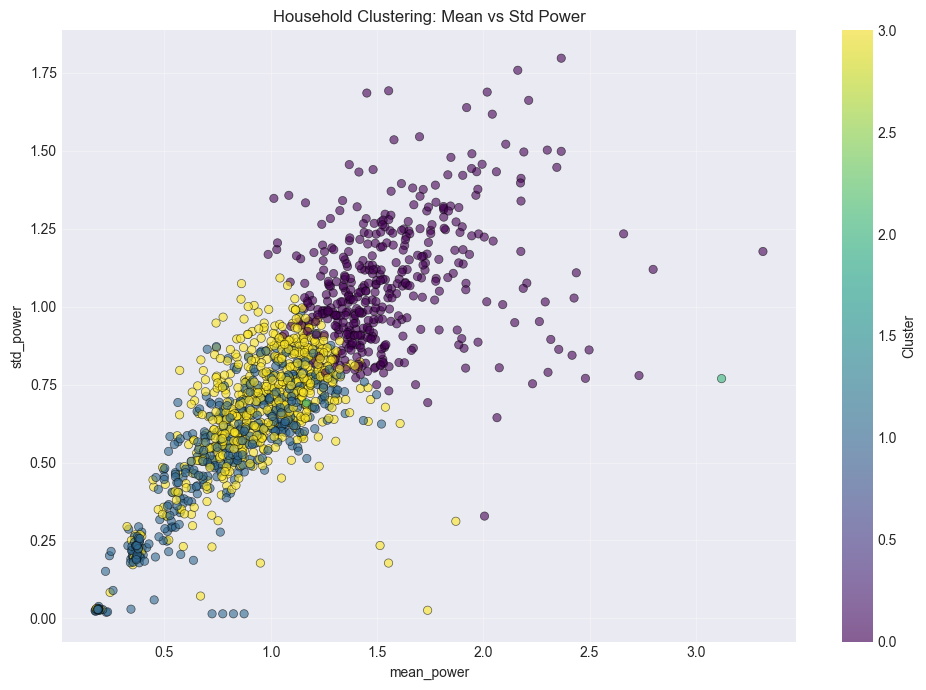

In [16]:
# Visualize using 2 key features
viz = PowerVisualizer(config_path='../configs/params.yaml')

viz.plot_clusters(
    df_profiles,
    labels_kmeans,
    feature_x='mean_power',
    feature_y='std_power',
    title='Household Clustering: Mean vs Std Power',
    filename='03_clusters_scatter.png'
)
plt.show()

Saved figure to outputs\figures\03_cluster_profiles.png


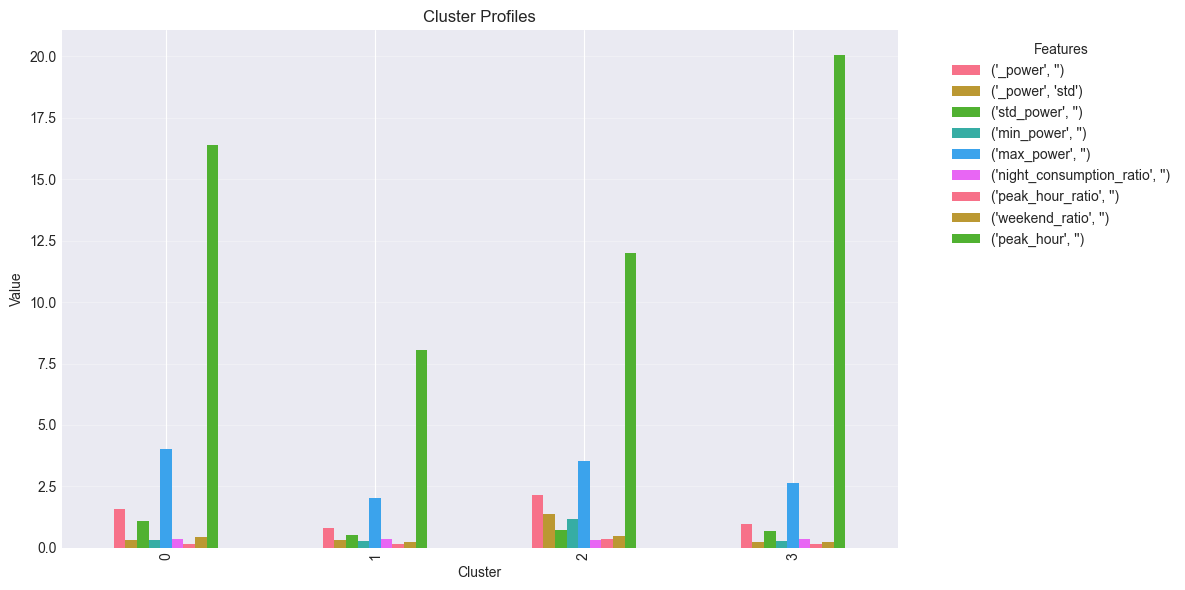

In [17]:
# Plot cluster profiles
viz.plot_cluster_profiles(
    profiles,
    filename='03_cluster_profiles.png'
)
plt.show()

### 2.9 Save Clustering Results

In [18]:
# Save cluster profiles
reporter.create_cluster_profile_table(
    profiles,
    filename='cluster_profiles.csv'
)

# Save cluster labels
df_profiles['cluster'] = labels_kmeans
loader.save_processed_data(df_profiles, 'profiles_with_clusters.parquet')

Saved cluster profiles to outputs\tables\cluster_profiles.csv

CLUSTER PROFILES
        mean_power         std_power         min_power         max_power         night_consumption_ratio        peak_hour_ratio         weekend_ratio         peak_hour        
              mean     std      mean     std      mean     std      mean     std                    mean    std            mean     std          mean     std      mean     std
cluster                                                                                                                                                                        
0           1.5635  0.3191    1.0732  0.2005    0.3270  0.1592    4.0018  0.7731                  0.3750  0.000          0.1667  0.0000        0.4466  0.4977   16.3835  4.5121
1           0.8050  0.3055    0.5332  0.2262    0.2708  0.0848    2.0463  0.7775                  0.3750  0.000          0.1667  0.0000        0.2230  0.4168    8.0587  3.8144
2           2.1440  1.3807    0.7302  0.

## Summary

In [19]:
print("=" * 80)
print("ASSOCIATION MINING & CLUSTERING SUMMARY")
print("=" * 80)

print("\n1. ASSOCIATION MINING:")
print(f"   - Transactions: {len(transactions)}")
print(f"   - Frequent itemsets: {len(frequent_itemsets)}")
print(f"   - Association rules: {len(rules_filtered)}")
print(f"   - Top lift: {rules_filtered['lift'].max():.2f}")

print("\n2. CLUSTERING:")
print(f"   - Profiles: {len(df_profiles)}")
print(f"   - Clusters: {metrics_kmeans['n_clusters']}")
print(f"   - Silhouette Score: {metrics_kmeans['silhouette_score']:.4f}")
print(f"   - Best method: KMeans")

print("\n3. CLUSTER INTERPRETATIONS:")
for cluster_id, desc in interpretations.items():
    print(f"   Cluster {cluster_id}: {desc}")

print("\n" + "=" * 80)

ASSOCIATION MINING & CLUSTERING SUMMARY

1. ASSOCIATION MINING:
   - Transactions: 5766
   - Frequent itemsets: 45
   - Association rules: 30
   - Top lift: 3.74

2. CLUSTERING:
   - Profiles: 1442
   - Clusters: 4
   - Silhouette Score: 0.3796
   - Best method: KMeans

3. CLUSTER INTERPRETATIONS:
   Cluster 0: High consumption, high variability, night-owl
   Cluster 1: Low consumption, stable, night-owl
   Cluster 2: High consumption, high variability, night-owl
   Cluster 3: Low consumption, stable, night-owl

